# Projet Churn - Sujet 2
Analyse de la rétention client et évaluation du risque.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

## 1. Chargement et Nettoyage

In [ ]:
df = pd.read_csv('customer_churn_business_dataset.csv')
# On remplit les cases vides dans les plaintes
df['complaint_type'] = df['complaint_type'].fillna('Aucune Plainte')
df.head()

,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0
3,CUST_00004,Male,49,Australia,Dhaka,Individual,19,Mobile,Yearly,34,...,26.420822,Technical,5.0,1,0.83,0.15,100,Neutral,0,0
4,CUST_00005,Male,65,Bangladesh,Delhi,Individual,52,Web,Monthly,20,...,26.674579,Technical,4.0,0,0.65,0.44,21,Unsatisfied,1,0


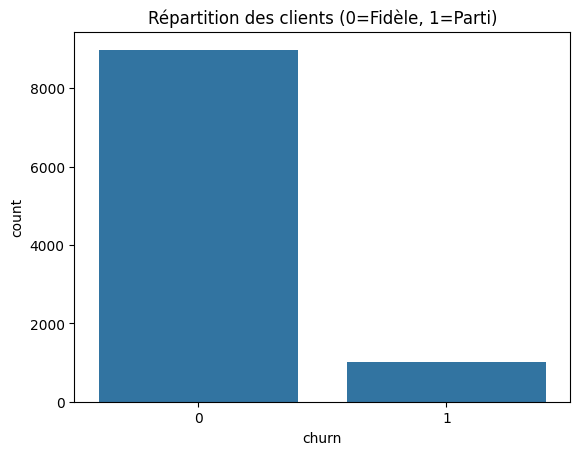

In [ ]:
# répartition du churn
sns.countplot(x='churn', data=df)
plt.title('Répartition des clients (0=Fidèle, 1=Parti)')
plt.show()

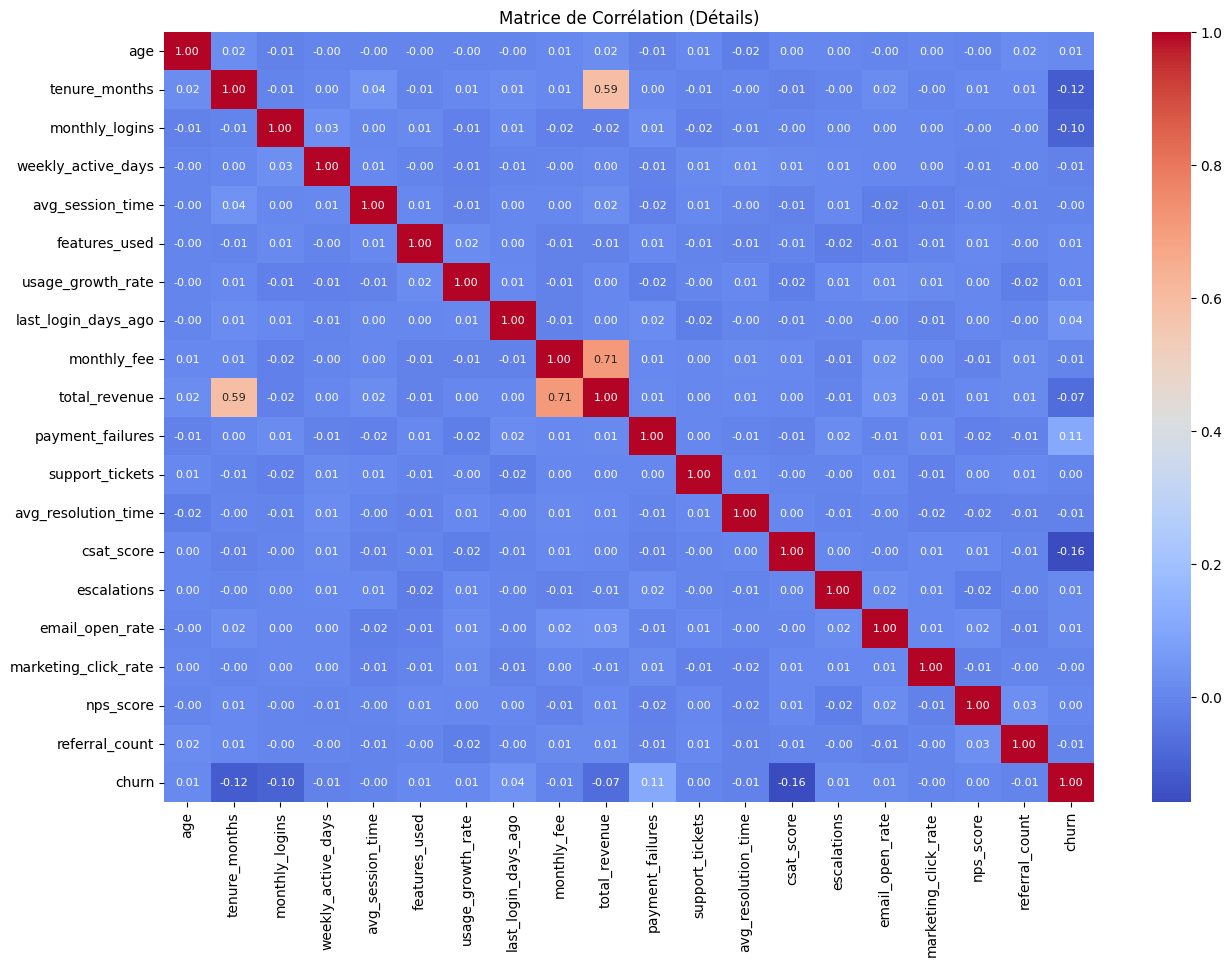

In [ ]:
# Matrice de corrélation
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', annot_kws={'size': 8})
plt.title('Matrice de Corrélation (Détails)')
plt.show()

## 2. Préparation des données

In [ ]:
# On n'enlève que l'ID et la cible, le reste est utile !
drop_list = ['churn', 'customer_id']
X = df.drop([c for c in drop_list if c in df.columns], axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

num_cols = X.select_dtypes(exclude=['object']).columns.tolist()
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f'Nombre de variables prédictives : {len(X.columns)}')


# Création du preprocesseur (très important pour éviter les erreurs !)
pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])


Nombre de variables prédictives : 30


## 3. Comparaison des modèles

In [ ]:
from sklearn.model_selection import cross_validate

modeles = {
    'LogisticRegression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'RandomForest': RandomForestClassifier(class_weight='balanced'),
    'XGBoost': XGBClassifier(),
    'DeepLearning (MLP)': MLPClassifier(hidden_layer_sizes=(32,16), max_iter=500)
}

# On définit les métriques qu'on veut tester
metrics = ['accuracy', 'recall', 'f1']

print(f'{"Modèle":20} | {"Acc":5} | {"Recall":6} | {"F1":5}')
print('-'*45)

for nom, m in modeles.items():
    p = Pipeline([('pre', pre), ('model', m)])
    # On calcule les 3 métriques en Cross-Validation
    scores = cross_validate(p, X_train, y_train, cv=5, scoring=metrics)
    
    acc = scores['test_accuracy'].mean()
    rec = scores['test_recall'].mean()
    f1 = scores['test_f1'].mean()
    
    print(f'{nom:20} | {acc:.2f}  | {rec:.2f}    | {f1:.2f}')

Modèle               | Acc   | Recall | F1   
---------------------------------------------
LogisticRegression   | 0.68  | 0.65    | 0.29
RandomForest         | 0.90  | 0.00    | 0.00
XGBoost              | 0.89  | 0.11    | 0.17


c:\Users\amina\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


DeepLearning (MLP)   | 0.83  | 0.23    | 0.22


## 4. Modèle final et Importance des variables

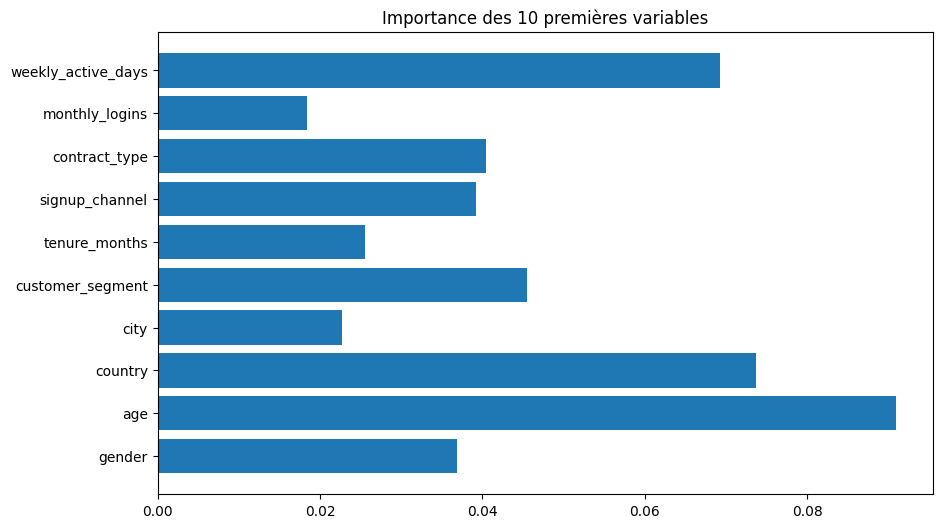

In [ ]:
# On garde le Random Forest comme modèle final
final_p = Pipeline([('pre', pre), ('model', RandomForestClassifier(class_weight='balanced', random_state=42))])
final_p.fit(X_train, y_train)

# Importance des variables
importances = final_p.named_steps['model'].feature_importances_
plt.figure(figsize=(10,6))
plt.barh(X.columns[:10], importances[:10])
plt.title('Importance des 10 premières variables')
plt.show()

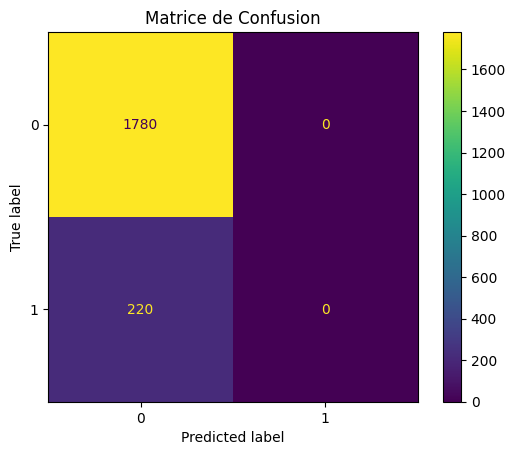

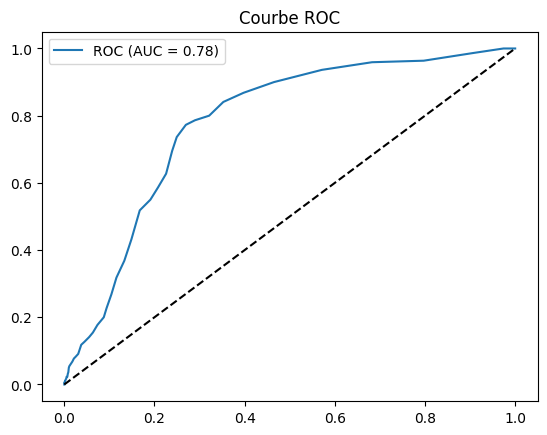

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Matrice de Confusion
y_pred = final_p.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Matrice de Confusion')
plt.show()

# 2. Courbe ROC
y_proba = final_p.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.title('Courbe ROC')
plt.show()

In [ ]:
# --- ANALYSE IMPACT BUSINESS ---

# 1. Calcul du Revenu à Risque (Stabilisation du CA)
y_proba_all = final_p.predict_proba(X)[:, 1]
df_impact = df.copy()
df_impact['probabilite_churn'] = y_proba_all

revenu_risque = df_impact[df_impact['probabilite_churn'] > 0.5]['monthly_fee'].sum()
print(f"Revenu mensuel à risque immédiat : {revenu_risque:.2f} €")

# 2. Priorisation des actions de rétention
top_10_priorites = df_impact.sort_values(by='probabilite_churn', ascending=False).head(10)
print("\nTop 10 des clients à contacter en priorité (Haute Probabilité) :")
print(top_10_priorites[['customer_id', 'probabilite_churn', 'monthly_fee']])

Revenu mensuel à risque immédiat : 27320.00 €

Top 10 des clients à contacter en priorité (Haute Probabilité) :
     customer_id  probabilite_churn  monthly_fee
3685  CUST_03686               0.87           50
5157  CUST_05158               0.86           20
2538  CUST_02539               0.85           50
678   CUST_00679               0.84           50
4007  CUST_04008               0.84           50
1348  CUST_01349               0.84           10
4725  CUST_04726               0.84           50
3124  CUST_03125               0.84           10
369   CUST_00370               0.84           50
8165  CUST_08166               0.83           50


In [ ]:
import joblib

# On crée et entraîne tous les modèles pour le Dashboard
export_models = {}
for nom, m in modeles.items():
    p = Pipeline([('pre', pre), ('model', m)])
    p.fit(X_train, y_train)
    export_models[nom] = p

medians = X.median(numeric_only=True).to_dict()

joblib.dump(export_models, 'all_models.pkl')
joblib.dump({
    'num': num_cols, 
    'cat': cat_cols, 
    'all': X.columns.tolist(),
    'medians': medians
}, 'features_info.pkl')

print("Les 4 modèles ont été sauvegardés !")

Les 4 modèles ont été sauvegardés !
